# Project: Twitter Sentiment Analysis

## 1. Business Understanding
### 1.1. Overview:

This project aims to build a Natural Language Processing (NLP) model capable of analyzing Twitter sentiments regarding Apple and Google products. The dataset consists of over 9,000 tweets that have been manually labeled as positive, negative, or neutral (neither). By analyzing customer opinions expressed on social media, organizations can gain insights into customer satisfaction, product perception, and emerging issues related to their products and services.

### 1.2. Problem Statement:
Organizations receive thousands of customer opinions daily through social media platforms such as Twitter. Manually analyzing these opinions is time-consuming and inefficient. Therefore, there is a need to develop an automated sentiment analysis model capable of accurately classifying tweets into positive, negative, or neutral sentiments to support data-driven decision-making and improve customer engagement strategies.To determine whether we can predict customer sentiments based of Tweets made on sold products. 

### 1.3. Key Business Questions

* Can customer sentiment toward Apple and Google products be accurately predicted using tweet content?
* What proportion of tweets express positive, negative, or neutral sentiments?
* Which products receive the most positive and negative feedback?
* What words or phrases are most commonly associated with positive and negative sentiments?
* How can sentiment insights help organizations improve products and customer satisfaction?
* Can social media sentiment be used as an indicator of public perception and brand reputation?

### 1.4. Metrics:

From a business perspective:

* Sentiment Distribution – Percentage of positive, negative, and neutral tweets.
* Brand Perception Insights – Overall sentiment trends toward Apple and Google products.
* Customer Satisfaction Indicators – Proportion of positive versus negative opinions.
* Actionable Insights – Identification of recurring themes and concerns expressed by customers.

From a model perspective:

* Accuracy - To know how well our model is performing
* Confusion Matrix – Evaluates the classification performance across sentiment classes.

### 1.5 Objectives

#### Main Objective

To build a machine learning model capable of accurately classifying the sentiment of tweets related to Apple and Google products.

#### Specific Objectives
1. To explore and understand the characteristics of the Twitter sentiment dataset.
2. To preprocess tweet text through cleaning, tokenization, stopword removal, and text normalization.
3. To perform exploratory data analysis (EDA) to identify patterns and trends in customer sentiments.
4. To extract meaningful text features using techniques such as TF-IDF vectorization.
5. To train and evaluate machine learning models for sentiment classification.
6. To compare model performance using appropriate evaluation metrics.
7. To identify the most influential words and phrases contributing to positive and negative sentiments.
8. To provide business insights based on sentiment analysis results.

# 2. Data Understanding

## 2.1 Importing the relevant libraries

In [223]:
# Importing the relevant libraries

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer
import tensorflow as tf
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from lime import lime_tabular
import warnings
from IPython.display import display, HTML
import IPython.core.display as core_display
warnings.filterwarnings('ignore')
%matplotlib inline

## 2.2 Loading and Previewing the data

In [76]:
# Loading the data

df = pd.read_csv(
    'Data\judge-1377884607_tweet_product_company.csv',
     encoding='ISO-8859-1'
    )
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [78]:
df.shape

(9093, 3)

### Summary
The data contains 9,093 data entries(rows) and is grouped under three features(columns).

The dataset features are:
1. tweet_text which contains the text entries of the users.
2. emotion_in_tweet_is_directed_at which contains the target product of the tweet_text, either Google or Apple.
3. is_there_an_emotion_directed_at_a_brand_or_product which contains the mood of the tweet_text on whether it is positive, negative or neither.


##  2.3 EXPLORATORY DATA ANALYSIS (EDA)

### 2.3.1 Checking the values in the feature 'is_there_an_emotion_directed_at_a_brand_or_product'

In [79]:
# Checking the column values and the distribution
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

is_there_an_emotion_directed_at_a_brand_or_product
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64

In [80]:
# Standardizing the data by merging the related values
mapping = {
    "Positive emotion" : 'positive',
    "Negative emotion" : 'negative',
    "No emotion toward brand or product" : 'neither',
    "I can't tell" : 'neither'
}

# Assigning the changes to column 'review'
df['review'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].replace(mapping)

In [81]:
df['review'].value_counts()

review
neither     5545
positive    2978
negative     570
Name: count, dtype: int64

In [82]:
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,review
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,negative
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,positive
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,positive
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,negative
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,positive


### 2.3.2 Checking the values in the feature 'emotion_in_tweet_is_directed_at'

In [83]:
# Checking the column values and the distribution
df['emotion_in_tweet_is_directed_at'].value_counts()

emotion_in_tweet_is_directed_at
iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: count, dtype: int64

In [84]:
# Standardizing the data by merging the related values
mapping = {
    'iPad':'Apple',
    'iPhone':'Apple',
    'iPad or iPhone App':'Apple',
    'Other Apple product or service':'Apple',
    'Android':'Google',
    'Android App':'Google',
    'Other Google product or service':'Google'
}

# Assigning the changes to column 'target_group'
df['target_group'] = df['emotion_in_tweet_is_directed_at'].replace(mapping)

In [85]:
df['target_group'].value_counts()

target_group
Apple     2409
Google     882
Name: count, dtype: int64

In [86]:
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product,review,target_group
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion,negative,Apple
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion,positive,Apple
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion,positive,Apple
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion,negative,Apple
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,positive,Google


### 2.3.3 Dropping the redundant features

In [87]:
# Dropping unwanted columns
new_df = df.drop(columns=['emotion_in_tweet_is_directed_at', 'is_there_an_emotion_directed_at_a_brand_or_product'])

## 2.4. Cleaning Data

### 2.4.1 Checking for missing values and duplicates

In [88]:
# Check for missing values
print("Missing Values:")
print(new_df.isnull().sum())
print(f"\nTotal Missing Values: {new_df.isnull().sum().sum()}")

print("\n" + "="*50)

# Check for duplicates
print(f"\nTotal Duplicate Rows: {new_df.duplicated().sum()}")

Missing Values:
tweet_text         1
review             0
target_group    5802
dtype: int64

Total Missing Values: 5803


Total Duplicate Rows: 22


The data set has 5,803 missing values with tweet_text having 1 missing value, and target_group having 5,802 missing values. While the total number of duplicates are 22. 

### 2.4.2 Dropping duplicates and filling missing values

In [89]:
# 1. Drop duplicate rows
new_df = new_df.drop_duplicates()
print(f"Shape after dropping duplicates: {new_df.shape}")

# 2. Fill missing values for categorical columns with mode
# funder, installer, subvillage, permit have missing values
new_df = new_df.dropna(subset=['tweet_text'])

# Apple and Google keywords
apple_keywords = ['apple', 'ipad', 'iphone', 'mac', 'ios']
google_keywords = ['google', 'android', 'gmail', 'chrome', 'youtube']

for idx in new_df[new_df['target_group'].isna()].index:

    tweet = str(new_df.loc[idx, 'tweet_text']).lower()

    if any(keyword in tweet for keyword in apple_keywords):
        new_df.loc[idx, 'target_group'] = 'Apple'

    elif any(keyword in tweet for keyword in google_keywords):
        new_df.loc[idx, 'target_group'] = 'Google'

    else:
        new_df.loc[idx, 'target_group'] = 'Unknown'

# 3. Confirm no missing values remain
print(f"\nRemaining Missing Values: {new_df.isnull().sum().sum()}")
# 4Find the number of duplicated records
print(f"\nTotal Duplicate Rows: {df.duplicated().sum()}")
print(f"\nFinal Shape: {new_df.shape}")

Shape after dropping duplicates: (9071, 3)



Remaining Missing Values: 0

Total Duplicate Rows: 22

Final Shape: (9070, 3)


After cleaning the data that includes, dropping the duplicates and filling/dropping the missing values, the data's final number of data entries is 9,070 rows. The data has no missing values.

### 2.4.3 Checking for outliers

In [90]:
# Calculate the number of characters and sentences
new_df['num_of_characters'] = new_df['tweet_text'].str.len()
new_df['num_of_sentences'] = new_df['tweet_text'].apply(lambda x: len(nltk.sent_tokenize(x)))

# Generate descriptive statistics
description = new_df[['num_of_characters', 'num_of_sentences']].describe()

# Display the descriptive statistics
print(description)

       num_of_characters  num_of_sentences
count        9070.000000       9070.000000
mean          104.959647          1.881036
std            27.202956          0.942651
min            11.000000          1.000000
25%            86.000000          1.000000
50%           109.000000          2.000000
75%           126.000000          2.000000
max           178.000000          7.000000


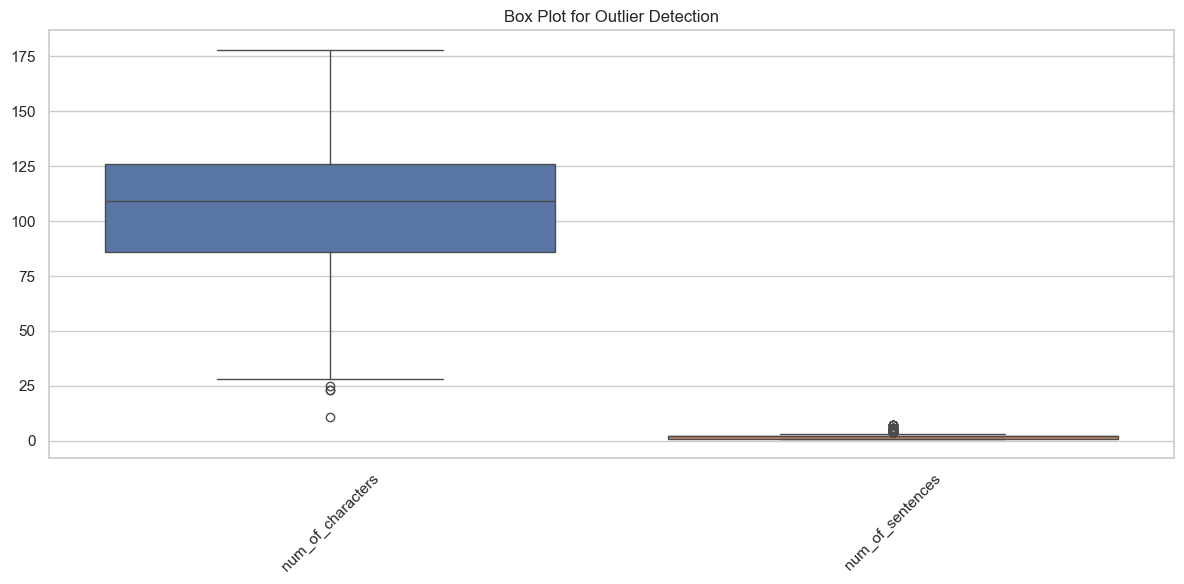

In [91]:
# Set style for better visuals
sns.set(style="whitegrid")

# Plot boxplots for all numeric columns
plt.figure(figsize=(12, 6))
sns.boxplot(data=new_df[['num_of_characters', 'num_of_sentences']])

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.title("Box Plot for Outlier Detection")
plt.tight_layout()
plt.show()

From the box plot above on the number of characters, majority of the the tweets range from slightly above 25 characters to slightly above 175 characters with majority of the data clustered from slightly above 125 characters and between 75 and 100 characters. The box plot on the number of sentences, the number of sentences in the tweets are clustered between 1 and 5 with the marojity of the number of sentences being 2 sentences.  

In [92]:
# Checking tweets lying outside the lower skewer of the number of characters
new_df[new_df['num_of_characters'] < 25]

,tweet_text,review,target_group,num_of_characters,num_of_sentences
3837,My #sxsw iPhone screen.,neither,Apple,23,1
5025,RT @mention,neither,Unknown,11,1
8112,At Apple store at #sxsw,neither,Apple,23,1


In [93]:
# Checking tweets lying outside the upper skewer of the number of characters
new_df[new_df['num_of_sentences'] > 5]

,tweet_text,review,target_group,num_of_characters,num_of_sentences
21,"Oh. My. God. The #SXSW app for iPad is pure, u...",positive,Apple,127,6
176,Attending #SXSWi? Work in iPhone / iPad game d...,neither,Apple,136,6
1287,You won't use glasses? Lies. Lies. It's a phon...,neither,Apple,124,7
2159,÷¼ WHO? WHAT? WHERE? WHEN? WHY? ÷_ {link} ã...,neither,Unknown,102,6
4003,Can't. Take. Hands. Off. iPhone. Even when it...,positive,Apple,107,7
5851,RT @mention Google Party is at GSD&amp;M (Goog...,positive,Google,145,7
7181,Come! &quot;@mention Google Party is at GSD&am...,positive,Google,144,7
7625,Making sure I packed everything I need for #sx...,neither,Apple,114,7
7795,Google Party is at GSD&amp;M (Google Map it). ...,positive,Google,133,7
7840,"2 iPad 2's acquired. In line at 9:30a, store o...",positive,Apple,121,6


## 2.5 Univariate Analysis
Comparing each variable at a time.

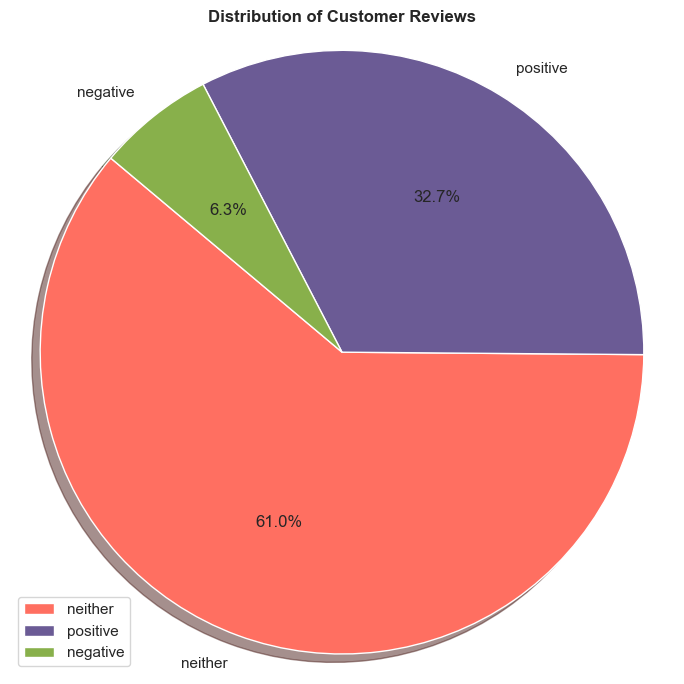

In [94]:
# Count the occurrences of each category
review_counts = new_df['review'].value_counts()

# Define colors for each category (3 colors)
colors = ['#FF6F61', '#6B5B95', "#88B04B"]

# Create the pie chart
plt.figure(figsize=(7,7))
plt.pie(review_counts, labels=review_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, shadow=True)

plt.title('Distribution of Customer Reviews', fontweight='bold')
plt.axis('equal') # Equal aspect ratio ensures that the pie is drawn as a circle

# Display the chart
plt.tight_layout()
plt.legend()
plt.show()

### Key Insights

* Most customers gave **neutral reviews** (61%), indicating that many reviews are neither strongly positive nor negative.
* **Positive reviews** make up nearly one-third of the total, suggesting a generally favorable customer sentiment among those expressing an opinion.
* **Negative reviews** are relatively rare (6.3%), indicating low levels of dissatisfaction.

### Overall Interpretation

The review distribution suggests that customer sentiment is largely **neutral**, with **positive feedback significantly outweighing negative feedback**. This could indicate that while many customers have moderate or mixed experiences, the overall perception is more favorable than unfavorable.


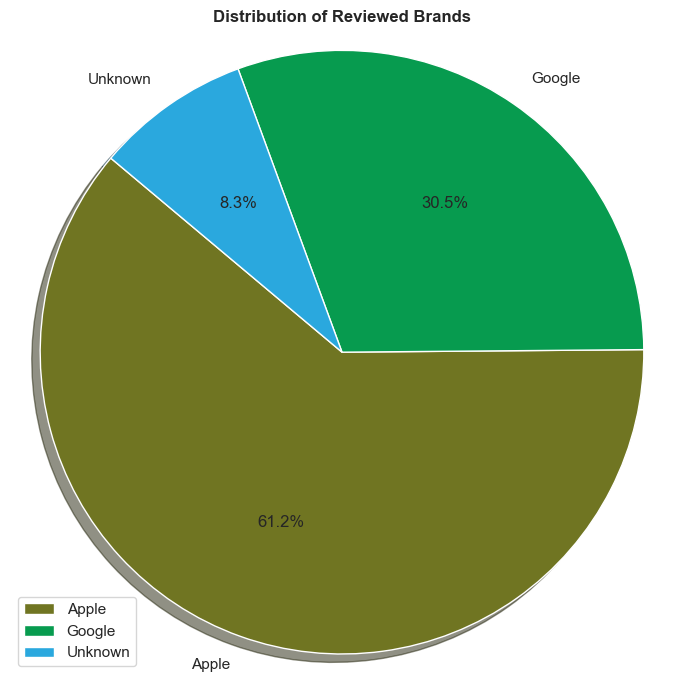

In [95]:
# Count the occurrences of each category
target_counts = new_df['target_group'].value_counts()

# Define colors for each category (3 colors)
colors = ["#707522", "#079B4F", "#2AA8DE"]

# Create the pie chart
plt.figure(figsize=(7,7))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, shadow=True)

plt.title('Distribution of Reviewed Brands', fontweight='bold')
plt.axis('equal') # Equal aspect ratio ensures that the pie is drawn as a circle

# Display the chart
plt.tight_layout()
plt.legend()
plt.show()

### Key observations

* Apple accounts for **more than three-fifths** of the total reviews.
* Apple and Google together make up **91.7%** of all reviewed brands, indicating that the dataset is heavily concentrated on these two brands.
* The **Unknown** category represents a relatively small portion of the reviews.

### Overall interpretation

The reviewed brands are strongly skewed toward Apple, with Google being the second most frequently reviewed brand. Very few reviews could not be associated with a known brand. This suggests that the dataset is primarily focused on Apple and Google products or services.


## 2.6 Bivariate Analysis

In this part we evaluate relationship between the feature columns and the target column (review)

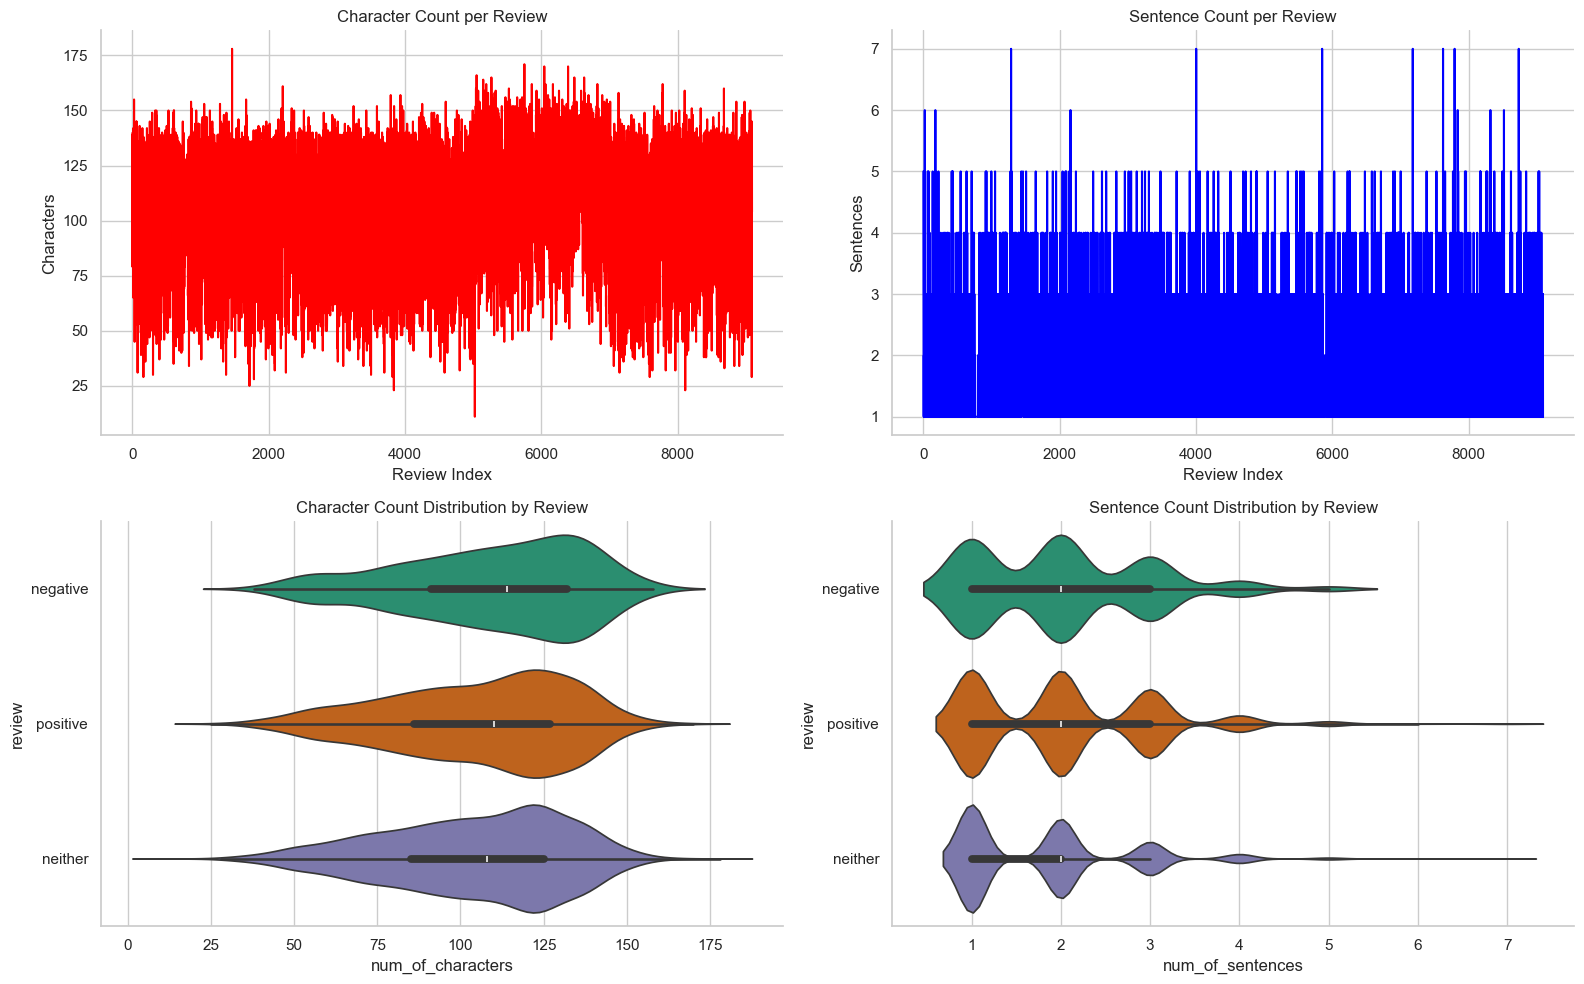

In [96]:
# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot num_of_characters line plot in the first subplot with a specific color
new_df['num_of_characters'].plot(
    kind='line',
    color='red',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Character Count per Review')
axes[0, 0].set_xlabel('Review Index')
axes[0, 0].set_ylabel('Characters')
axes[0, 0].spines[['top', 'right']].set_visible(False)

# Plot num_of_sentences line plot in the first subplot with a specific color
new_df['num_of_sentences'].plot(
    kind='line',
    color='blue',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Sentence Count per Review')
axes[0, 1].set_xlabel('Review Index')
axes[0, 1].set_ylabel('Sentences')
axes[0, 1].spines[['top', 'right']].set_visible(False)

# Violin plot for num_of_characters by review
sns.violinplot(
    data=new_df,
    x='num_of_characters',
    y='review',
    inner='box',
    palette='Dark2',
    ax=axes[1, 0]
)

axes[1, 0].set_title('Character Count Distribution by Review')
axes[1, 0].spines[['top', 'right']].set_visible(False)

# Violin plot for num_of_sentences by review
sns.violinplot(
    data=new_df,
    x='num_of_sentences',
    y='review',
    inner='box',
    palette='Dark2',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Sentence Count Distribution by Review')
axes[1, 1].spines[['top', 'right']].set_visible(False)

# Improve spacing
plt.tight_layout()

plt.show()

The figure presents a **multivariate exploratory analysis of text-length characteristics** across three sentiment classes (**positive, negative, and neither**). It consists of two line plots and two violin plots.

### In summary:

* From the top left plot, the dataset contains moderately sized texts with no extreme variation, which is beneficial for NLP modeling since document lengths are fairly uniform. 
* From the top right plot, the corpus is dominated by short reviews, which is typical for social media posts, comments, or brief product reviews. 
* From the bottom left plot, the violin plots compare character count distributions across sentiment categories. The three sentiment classes exhibit very similar character-count distributions, this suggests that review length alone may not be a strong predictor of sentiment. 
* From the bottom right plot, the violin plots illustrate the number of sentences across sentiment categories. Sentence count distributions overlap substantially across all sentiment categories. Therefore, sentence count is unlikely to be a highly discriminative feature for sentiment classification.


# 3. Data Preprocessing

In [97]:
nltk.download('punkt') # for tokenization
nltk.download('stopwords') # for removing stopwords
nltk.download('wordnet')   # for lemmatization

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\benbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\benbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\benbe\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [98]:
# Initialize once
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def processed_text(text):
    # Remove URLs
    text = re.sub(r'http[s]?://\S+', ' ', text)

    # Remove markdown links
    text = re.sub(r'\[.*?\]\(.*?\)', ' ', text)

    # Remove Twitter handles
    text = re.sub(r'@\w+', ' ', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into text
    return ' '.join(tokens)

# Create processed_text column
new_df['preprocessed_text'] = new_df['tweet_text'].apply(processed_text)

new_df.head()

,tweet_text,review,target_group,num_of_characters,num_of_sentences,preprocessed_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,negative,Apple,127,5,g iphone hr tweeting rise_austin dead need upg...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,positive,Apple,139,3,know awesome ipad iphone app likely appreciate...
2,@swonderlin Can not wait for #iPad 2 also. The...,positive,Apple,79,2,wait ipad also sale sxsw
3,@sxsw I hope this year's festival isn't as cra...,negative,Apple,82,2,hope year festival crashy year iphone app sxsw
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,positive,Google,131,1,great stuff fri sxsw marissa mayer google tim ...


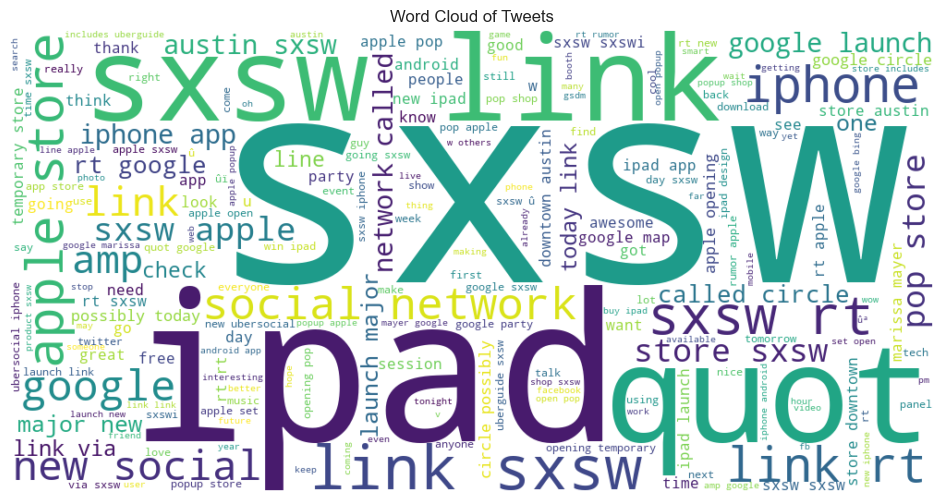

In [100]:
# Combine all processed text into one string
text = ' '.join(new_df['preprocessed_text'])

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=200
).generate(text)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Tweets')
plt.show()

This combines **all tweets**, regardless of sentiment.

### Key observations:

* The most frequent terms overall are: **sxsw**, **ipad**, **link**, **apple**, **store**, **iphone**, **google**, **social**, **network** and **launch**.

* The cloud reflects the main themes of the conversation:
  * Mobile devices (iPad, iPhone, Android)
  * Technology companies (Apple, Google)
  * Apps and app stores
  * Social networking
  * Product launches and announcements

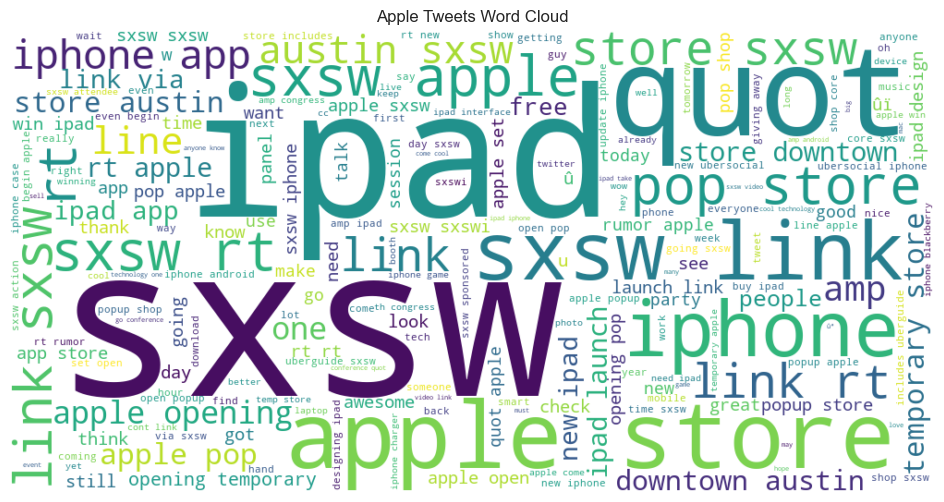

In [101]:
apple_text = ' '.join(
    new_df[new_df['target_group'] == 'Apple']['preprocessed_text']
)

apple_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(apple_text)

plt.figure(figsize=(12, 6))
plt.imshow(apple_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Apple Tweets Word Cloud')
plt.show()

### Key Observations:

* The most dominant words are **ipad**, **sxsw**, **apple**, **store**, **iphone**, **app**, and **link**.
* The prominence of **ipad** and **iphone** indicates that discussions are largely centered on Apple's flagship mobile devices.
* Frequent appearances of **store**, **opening**, **downtown**, and **austin** suggest significant discussion around Apple Store-related events.
* The term **sxsw** (South by Southwest) is highly dominant, indicating that many tweets were generated during or about the SXSW technology event.
* Words such as **launch**, **party**, **free**, and **pop** imply conversations related to product launches, promotions, and event activities.

### In Summary:

The Apple tweets focus heavily on Apple products, especially the iPad and iPhone, with much of the conversation linked to promotional activities and events occurring during SXSW. The overall vocabulary reflects customer engagement with product showcases, store openings, and app-related discussions.

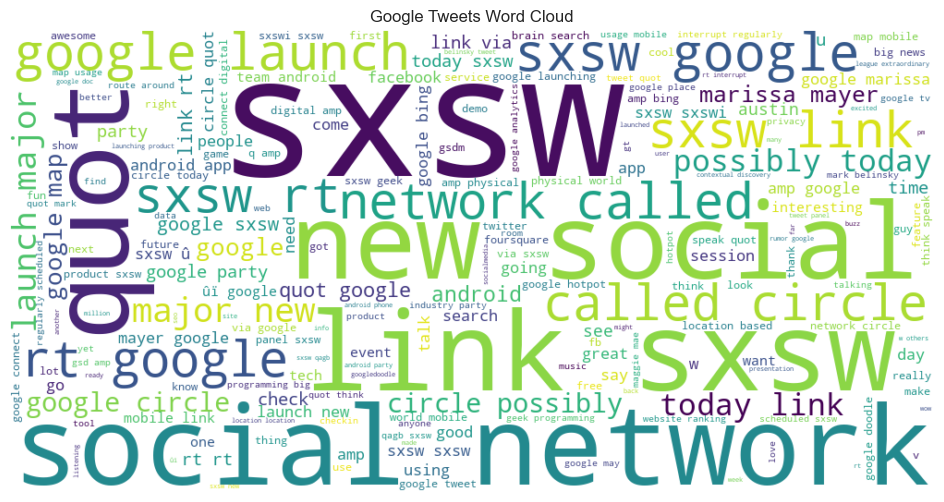

In [102]:
google_text = ' '.join(
    new_df[new_df['target_group'] == 'Google']['preprocessed_text']
)

google_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(google_text)

plt.figure(figsize=(12, 6))
plt.imshow(google_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Google Tweets Word Cloud')
plt.show()

### Key Observations

* The most prominent words are **"social"**, **"network"**, **"new"**, **"called"**, **"circle"**, **"google"**, **"launch"**, and **"sxsw"**.
* The phrase components **"social network called circle"** dominate the cloud, indicating extensive discussion about Google's social networking initiative, Google+ (originally rumored as Google Circle).
* Words such as **"launch"**, **"today"**, **"possibly"**, and **"called"** suggest speculation and anticipation surrounding a product announcement.
* Terms including **"android"**, **"search"**, and **"google"** indicate continued discussion of Google's core products and services.
* Similar to the Apple cloud, **"sxsw"** is highly frequent, confirming that many tweets were associated with the SXSW event.

### Interpretation

Google-related tweets are primarily focused on discussions of a new social networking platform and product launches. The conversation appears more centered on emerging services and industry announcements than on hardware products.

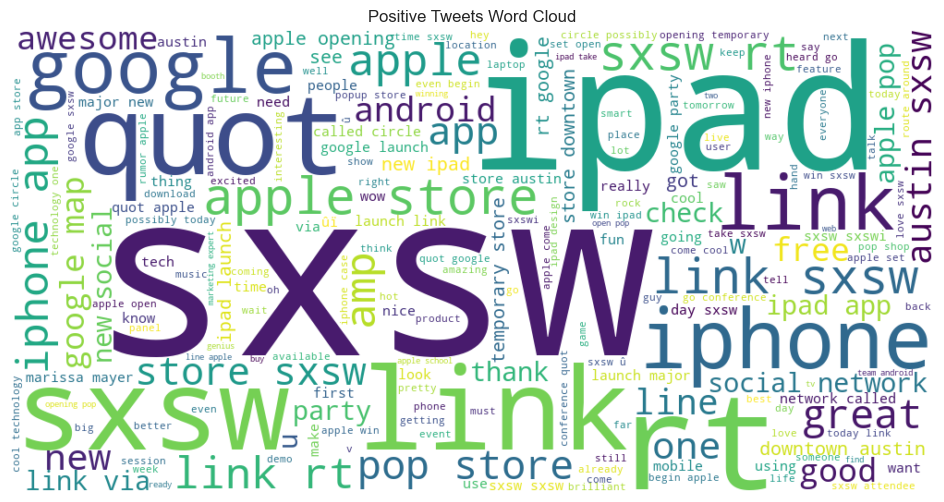

In [103]:
positive_text = ' '.join(
    new_df[new_df['review'] == 'positive']['preprocessed_text']
)

positive_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Tweets Word Cloud')
plt.show()

This cloud shows the most common words in **positive** tweets.

### Key observations:

* Again, **sxsw** is the largest word.
* Strongly represented terms include; **google**, **quot** (likely an artifact from tweet text processing),  **link**, **ipad**,  **iphone**, **apple**, **store**, **great**, **awesome**, **free** and **good**.
* Positive tweets contain more explicitly favorable words such as: **awesome**, **great**, **good** and **nice**.

### Interpretation:
Positive discussions revolve around technology launches, apps, Apple and Google products, conference activities, and excitement around SXSW-related announcements.


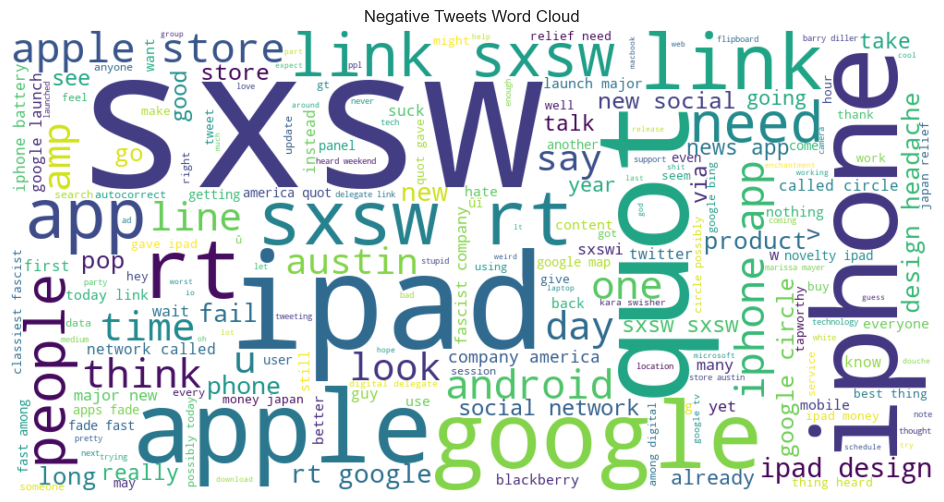

In [104]:
negative_text = ' '.join(
    new_df[new_df['review'] == 'negative']['preprocessed_text']
)

negative_wc = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Tweets Word Cloud')
plt.show()

This cloud highlights the most frequent words in tweets classified as **negative**.

### Key observations:

* **sxsw** is the dominant term, indicating the event is the main discussion topic.
* Other prominent words include; **ipad**, **apple**, **google**, **link**, **android**, **store**, **iphone**, **need** and **app**.
* Negative tweets appear to focus on:
  * Technical issues ("link", "app", "store")
  * Product discussions ("ipad", "iphone", "android")
  * Frustrations or unmet expectations ("need", "fail", "problem"-related terms appearing in smaller sizes)

### Interpretation:
Negative sentiment seems tied more to user experiences with apps, devices, links, or conference-related technology rather than strong criticism of a particular company.

# 4. Modelling

In [ ]:
# Assigning the features to X and y
X = new_df['preprocessed_text']
y = new_df['review']

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, stratify= y, random_state= 42)

## 4.1. Baseline Model: Random Forest Model

In [170]:
# Modeling
pipe = Pipeline([
    ('tfid', TfidfVectorizer(
        min_df=0.1,
        max_df=0.9
    )),
    # ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(
        class_weight = 'balanced',
        random_state=42))
])

In [171]:
# Training the model
pipe.fit(X_train, y_train)

# Predicting the model
y_pred_base = pipe.predict(X_test)

# Evaluating based on accuracy
test_acc = accuracy_score(y_test, y_pred_base)
test_acc

0.4210758377425044

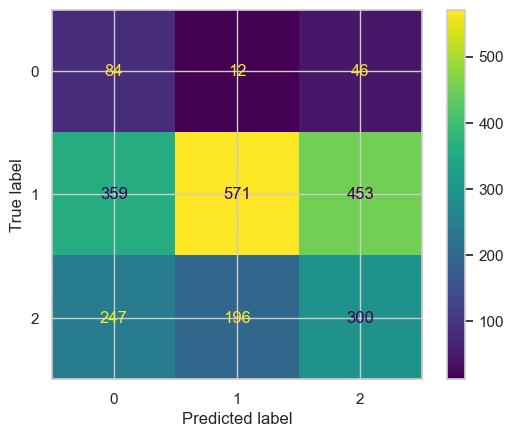

In [172]:
cfm = confusion_matrix(y_test, y_pred_base)

ConfusionMatrixDisplay(cfm).plot();

The values are:
- True 0: 84 / 12 / 46
- True 1: 359 / 571 / 453
- True 2: 247 / 196 / 300

Class 1 dominates the dataset by far (it has the most total samples), and while 571 of those are correctly predicted (the bright yellow cell), a large number leak into both class 0 (359) and class 2 (453). Class 0 has only 142 total samples and is correctly identified just 84 times, with notable confusion toward class 2. Class 2 (743 samples) is correctly classified only 300 times, with substantial spillover into both other classes (247 to class 0, 196 to class 1). Overall, the model shows weak separability, especially heavy bleed from class 1 into the other two classes.

### 4.1.2. Model 2: Optimized Random Forest Model

In [179]:
# Modeling
param_grid = {
    'tfid__ngram_range': [(1,1), (1,2)],
    'tfid__min_df': [2, 5],
    'clf__criterion':['gini', 'entropy'],
    'clf__max_depth': [None, 1, 2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 3],
    'clf__min_samples_split': [1, 5, 10, 20]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 10, 'tfid__min_df': 2, 'tfid__ngram_range': (1, 2)}
0.5429432910385689


In [180]:
# Improved Model
pipe_1 = Pipeline([
    ('tfid', TfidfVectorizer(
        ngram_range = (1, 2),
        min_df=2,
        max_df=0.9
    )),
    ('clf', RandomForestClassifier(
        class_weight = 'balanced',
        criterion='gini', 
        max_depth= None,
        min_samples_leaf = 2,
        min_samples_split= 10, 
        random_state=42
    ))
])

In [181]:
# Training the model
pipe_1.fit(X_train, y_train)

# Predicting the model
y_pred_dtc = pipe_1.predict(X_test)

# Evaluating based on accuracy
test_acc_1 = accuracy_score(y_test, y_pred_dtc)
test_acc_1

0.6547619047619048

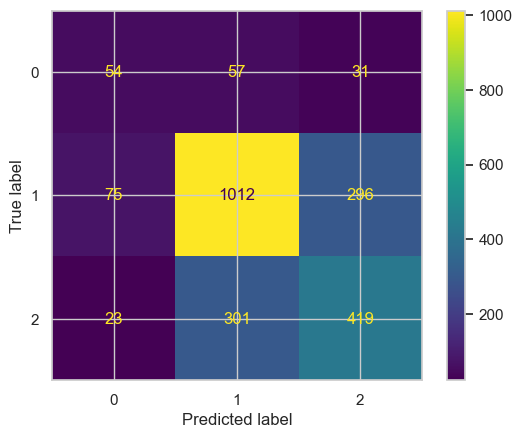

In [182]:
cfm = confusion_matrix(y_test, y_pred_dtc)

ConfusionMatrixDisplay(cfm).plot();

The values are:
- True 0: 54 / 57 / 31
- True 1: 75 / 1012 / 296
- True 2: 23 / 301 / 419

This matrix shows a much sharper diagonal for class 1, jumping from 571 to 1012 correct predictions, with confusion into class 0 nearly eliminated (359 → 75). Class 2's correct predictions also improved (300 → 419), and its confusion with class 0 dropped sharply (247 → 23), though confusion with class 1 remains similar (196 → 301). However, class 0 performance got worse: correct predictions dropped from 84 to 54, with more of its samples now misclassified as class 1 (12 → 57) while misclassification as class 2 stayed similar (46 → 31).

## 4.2. Model 3: Linear Support Vector Machine(SVM) Model

In [184]:
# Modeling
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2),
        min_df=5,
        max_df=0.9
    )),
    ('clf', LinearSVC(
        class_weight='balanced',
        C=1.0,
        random_state=42
    ))
])

In [185]:
# Training the model
svm_pipe.fit(X_train, y_train)

# Predicting the model
y_pred_svm = svm_pipe.predict(X_test)

# Evaluating based on accuracy
test_acc_2 = accuracy_score(y_test, y_pred_svm)
test_acc_2

0.667989417989418

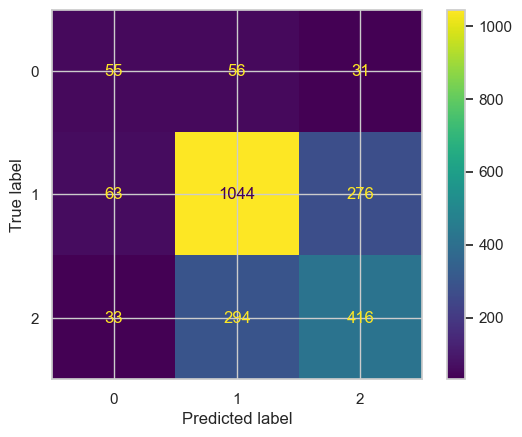

In [186]:
cfm = confusion_matrix(y_test, y_pred_svm)

ConfusionMatrixDisplay(cfm).plot();

The values are:

* True 0: 55 / 56 / 31
* True 1: 63 / 1044 / 276
* True 2: 33 / 294 / 416

This matrix looks very similar in pattern to the previous "opt" model: class 1 (the majority class) is predicted correctly the vast majority of the time (1044/1383), with a notable chunk of class 1 samples misclassified as class 2 (276). Class 0 remains the weakest, with only 55 of 142 correctly identified and roughly equal confusion with classes 1 and 2 (56 and 31). Class 2 is correctly classified 416/743 times, with substantial confusion toward class 1 (294).

### 4.2.2. Model 4: Tuned Support Vector Machine(SVM) Model

In [194]:
param_grid_svm = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [2, 5],
    'tfidf__max_df': [0.8, 0.9, 0.95],

    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__loss': ['hinge', 'squared_hinge'],
    'clf__dual': [True, False]
}

grid = GridSearchCV(
    svm_pipe,
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best Parameters:
{'clf__C': 0.1, 'clf__dual': True, 'clf__loss': 'squared_hinge', 'tfidf__max_df': 0.8, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best CV Score:
0.6733325409517223


In [197]:
# Modeling
svm_pipe_td = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.8
    )),
    ('clf', LinearSVC(
        dual = True,
        loss = 'squared_hinge',
        class_weight='balanced',
        C=0.1,
        random_state=42
    ))
])

In [198]:
# Training the model
svm_pipe_td.fit(X_train, y_train)

# Predicting the model
y_pred_svm = svm_pipe_td.predict(X_test)

# Evaluating based on accuracy
test_acc_3 = accuracy_score(y_test, y_pred_svm)
test_acc_3

0.6843033509700176

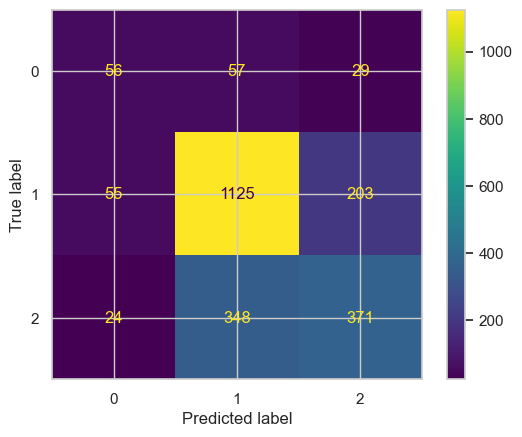

In [199]:
cfm = confusion_matrix(y_test, y_pred_svm)

ConfusionMatrixDisplay(cfm).plot();

The values are:

* True 0: 56 / 57 / 29
* True 1: 55 / 1125 / 203
* True 2: 24 / 348 / 371

The overall pattern is similar, but tuning shifted performance slightly: class 1's correct predictions increased from 1044 to 1125, and its confusion with class 2 dropped (276 → 203). However, class 2's own accuracy fell (416 → 371), with more of its samples now being misclassified as class 1 (294 → 348). Class 0 stayed essentially unchanged (55 → 56 correct).

## 4.3. Model 4: MultinomialNB Model

In [200]:
# Modeling
nlp_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df=0.01,   # ignore terms in < 1% of documents
        max_df=0.9     # ignore terms in > 90% of documents
    )),
    ('clf', MultinomialNB())
])

In [201]:
nlp_pipe.fit(X_train, y_train)

y_pred_nlp = nlp_pipe.predict(X_test)
test_acc_3 = accuracy_score(y_test, y_pred_nlp)
test_acc_3

0.6335978835978836

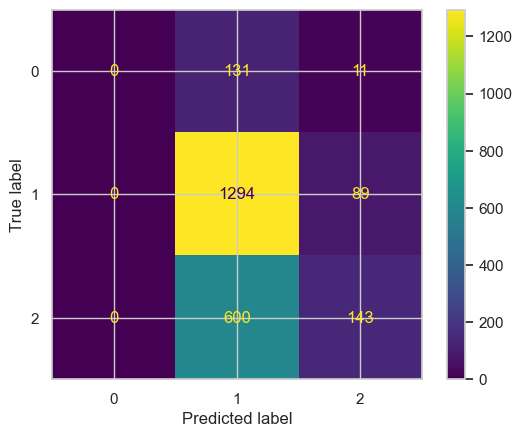

In [202]:
cfm = confusion_matrix(y_test, y_pred_nlp)

ConfusionMatrixDisplay(cfm).plot();

The values are:

* True 0: 0 / 131 / 11
* True 1: 0 / 1294 / 89
* True 2: 0 / 600 / 143

The first column is entirely zero — this model never predicts class 0 at all, so every true class-0 sample is misclassified (mostly into class 1). Class 1 has very high recall (1294/1383), while class 2 is mostly absorbed into class 1 (600 of 743).

### 4.3.2. Model 5: Tuned MultiNomialNB Model

In [203]:
param_grid_nlp = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [2, 5],
    'tfidf__max_df': [0.8, 0.9, 0.95],
    'tfidf__max_features': [5000, 10000],

    'clf__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]
}

grid_nb = GridSearchCV(
    nlp_pipe,
    param_grid_nlp,
    cv=5,
    scoring='f1_weighted',  # or 'accuracy'
    n_jobs=-1,
    verbose=2
)

grid_nb.fit(X_train, y_train)

print("Best Parameters:")
print(grid_nb.best_params_)

print("\nBest CV Score:")
print(grid_nb.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Parameters:
{'clf__alpha': 0.1, 'tfidf__max_df': 0.8, 'tfidf__max_features': 10000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Best CV Score:
0.6446421034624118


In [205]:
# Modeling
nlp_pipe_td = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features = 10000,
        ngram_range = (1, 2),
        min_df=2,   # ignore terms in < 1% of documents
        max_df=0.8     # ignore terms in > 90% of documents
    )),
    ('clf', MultinomialNB(alpha=0.1))
])

In [206]:
nlp_pipe_td.fit(X_train, y_train)

y_pred_nlp_td = nlp_pipe_td.predict(X_test)
test_acc_4 = accuracy_score(y_test, y_pred_nlp_td)
test_acc_4

0.6684303350970018

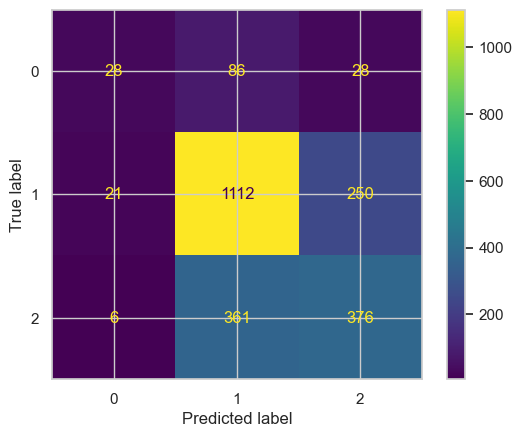

In [220]:
cfm = confusion_matrix(y_test, y_pred_nlp_td)

ConfusionMatrixDisplay(cfm).plot();

The values are:

* True 0: 28 / 86 / 28
* True 1: 21 / 1112 / 250
* True 2: 6 / 361 / 376

Tuning has clearly changed the model's behavior: class 0 is now predicted at all (the first column is no longer empty), and 28 of the 142 true class-0 samples are now correctly identified. However, this comes with trade-offs elsewhere: class 1's correct predictions dropped from 1294 to 1112, with more spillover into class 2 (89 -> 250). Class 2's correct predictions increased from 143 to 376, with reduced (but still substantial) confusion toward class 1 (600 -> 361).

## 4.4. Model 6: KNearestNeighbours Model

In [175]:
# Modeling
knn_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df=0.01,   # ignore terms in < 1% of documents
        max_df=0.9     # ignore terms in > 90% of documents
    )),
    ('clf', KNeighborsClassifier())
])

In [176]:
knn_pipe.fit(X_train, y_train)

y_pred_knn = knn_pipe.predict(X_test)
test_acc_3 = accuracy_score(y_test, y_pred_knn)
test_acc_3

0.6040564373897708

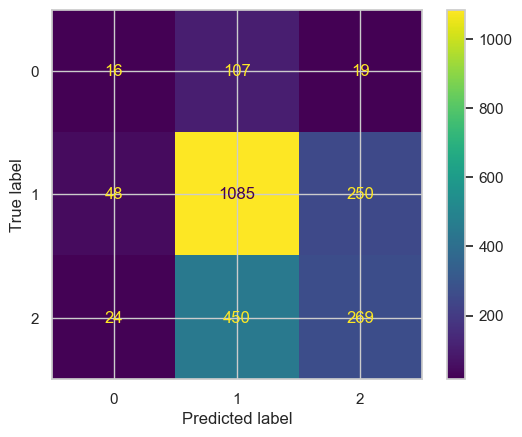

In [177]:
cfm = confusion_matrix(y_test, y_pred_knn)

ConfusionMatrixDisplay(cfm).plot();

The values are:
* True 0: 16 / 107 / 19
* True 1: 48 / 1085 / 250
* True 2: 24 / 450 / 269

Class 0 performs poorly here, with only 16 of 142 samples correctly classified, while a large majority (107) are misclassified as class 1. Class 1 again shows strong recall, with 1085 of 1383 correctly classified, and the remaining samples split between class 0 (48) and class 2 (250). Class 2 is correctly classified 269 of 743 times, but a substantial portion (450) is misclassified as class 1, with a smaller amount (24) going to class 0.

## 4.5. Model 7: Keras Sequential Model

In [ ]:
def create_model(meta):
    model = Sequential([
        Dense(
            512,
            activation='relu',
            input_shape=(meta["n_features_in_"],)
        ),
        Dropout(0.3),

        Dense(128, activation='relu'),
        Dropout(0.3),

        Dense(meta["n_classes_"], activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [213]:
nn_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        min_df=0.01,
        max_df=0.9
    )),
    ('clf', KerasClassifier(
        model=create_model,
        epochs=10,
        batch_size=32,
        verbose=0
    ))
])

In [217]:
nn_pipe.fit(X_train, y_train)

y_pred_nn = nn_pipe.predict(X_test)
test_acc_nn = accuracy_score(y_test, y_pred_nn)
test_acc_nn

0.6353615520282186

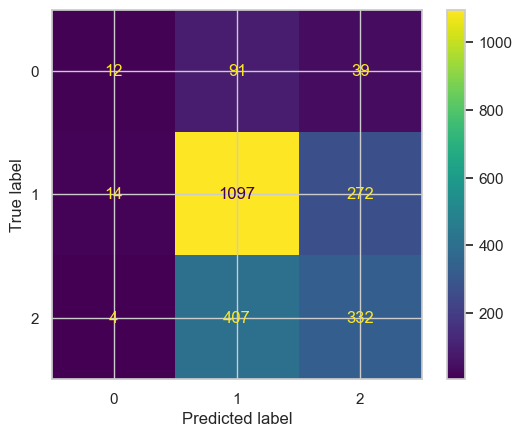

In [218]:
cfm = confusion_matrix(y_test, y_pred_nn)

ConfusionMatrixDisplay(cfm).plot();

The values are:
* True 0: 12 / 91 / 39
* True 1: 14 / 1097 / 272
* True 2: 4 / 407 / 332

Class 0 performs weakly, with only 12 of 142 samples correctly classified (≈8%), and the majority (91) misclassified as class 1, with another 39 going to class 2. Class 1 again shows very strong recall, with 1097 of 1383 correctly classified (≈79%), and a near-negligible number (14) misclassified as class 0, with 272 going to class 2. Class 2 is correctly classified 332 of 743 times (≈45%), though 407 samples are misclassified as class 1, and only 4 as class 0.

# 5. Model Evaluation